<a href="https://colab.research.google.com/github/HMBinara/ML_Project/blob/main/Human_Hydration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
#Import the libraies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('Daily_Water_Intake.csv')

Saving Daily_Water_Intake.csv to Daily_Water_Intake (2).csv


In [36]:
# cheak the colum and row

df.shape


(30000, 7)

In [37]:
# cheak the some information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          30000 non-null  int64  
 1   Gender                       30000 non-null  object 
 2   Weight (kg)                  30000 non-null  int64  
 3   Daily Water Intake (liters)  30000 non-null  float64
 4   Physical Activity Level      30000 non-null  object 
 5   Weather                      30000 non-null  object 
 6   Hydration Level              30000 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 1.6+ MB


In [38]:
#chaeking the missing value

df.isnull().sum()

,0
Age,0
Gender,0
Weight (kg),0
Daily Water Intake (liters),0
Physical Activity Level,0
Weather,0
Hydration Level,0


In [39]:
#show the frist row

df.head()

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,Male,96,4.23,Moderate,Hot,Good
1,60,Male,105,3.95,High,Normal,Good
2,36,Male,68,2.39,Moderate,Cold,Good
3,19,Female,74,3.13,Moderate,Hot,Good
4,38,Male,77,2.11,Low,Normal,Poor


In [40]:
#Encoded Gender
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])


#Encoded Activity Level (Mapping String Specific Number)
df['Physical Activity Level'] =df['Physical Activity Level'].map({'Low': 0,'Moderate': 1,'High': 2})

df.head()

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,1,96,4.23,1,Hot,Good
1,60,1,105,3.95,2,Normal,Good
2,36,1,68,2.39,1,Cold,Good
3,19,0,74,3.13,1,Hot,Good
4,38,1,77,2.11,0,Normal,Poor


In [41]:
#One-Hot Encoding Weather
df = pd.get_dummies(df, columns=['Weather'], prefix='Weather')
df.head()

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Hydration Level,Weather_Cold,Weather_Hot,Weather_Normal
0,56,1,96,4.23,1,Good,False,True,False
1,60,1,105,3.95,2,Good,False,False,True
2,36,1,68,2.39,1,Good,True,False,False
3,19,0,74,3.13,1,Good,False,True,False
4,38,1,77,2.11,0,Poor,False,False,True


In [42]:
#Drop the Hydration Level
df = df.drop('Hydration Level', axis=1)
df.head()

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather_Cold,Weather_Hot,Weather_Normal
0,56,1,96,4.23,1,False,True,False
1,60,1,105,3.95,2,False,False,True
2,36,1,68,2.39,1,True,False,False
3,19,0,74,3.13,1,False,True,False
4,38,1,77,2.11,0,False,False,True


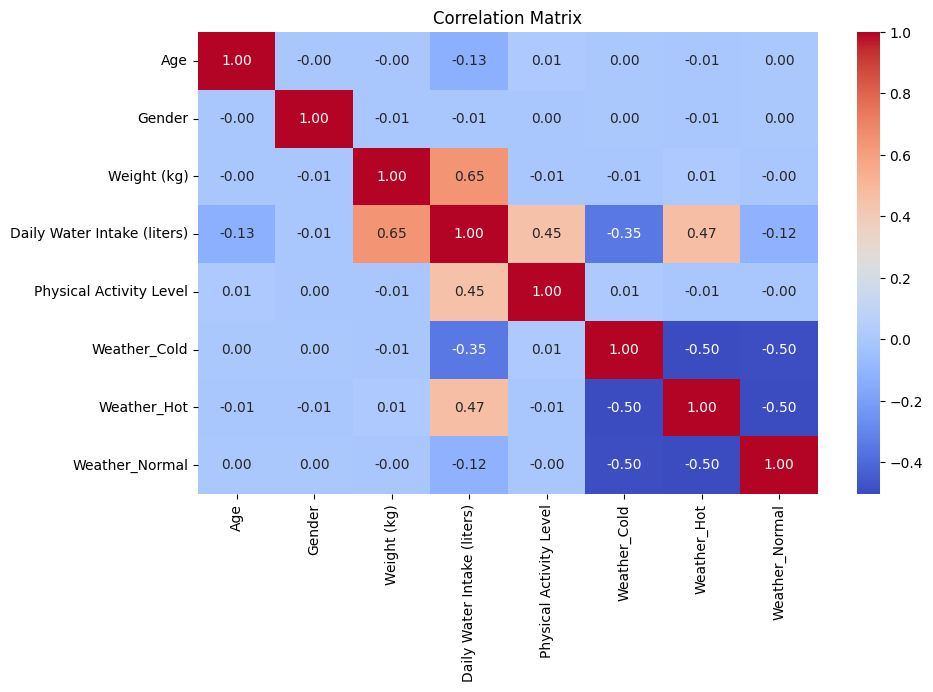

In [43]:
#Draw the Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()


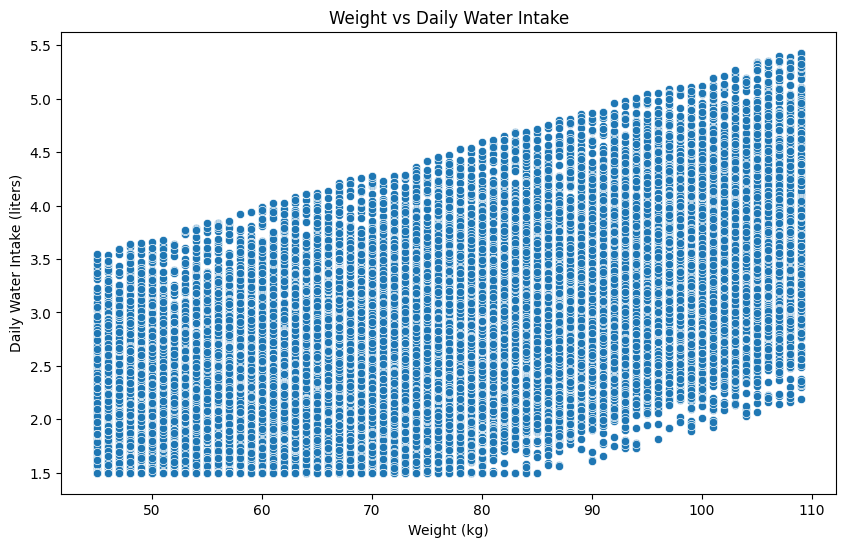

In [44]:
#Disribution Plot weight to Daily Water Intake
plt.figure(figsize=(10,6))
sns.scatterplot(x='Weight (kg)', y='Daily Water Intake (liters)', data=df)
plt.title("Weight vs Daily Water Intake")
plt.xlabel("Weight (kg)")
plt.ylabel("Daily Water Intake (liters)")
plt.show()

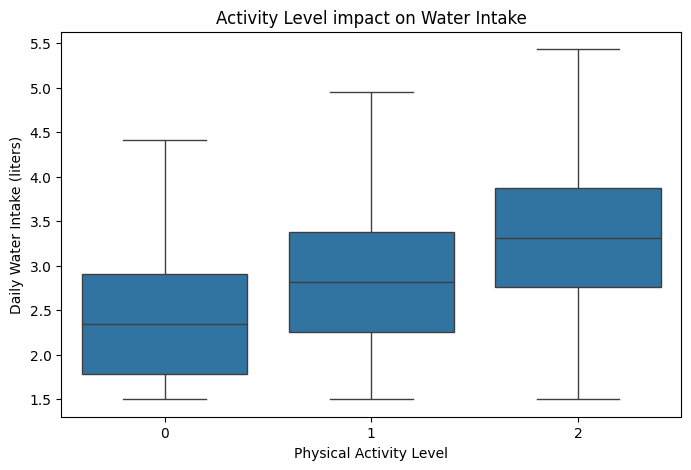

In [45]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Physical Activity Level', y='Daily Water Intake (liters)', data=df)
plt.title("Activity Level impact on Water Intake")
plt.show()

In [46]:
#Train the Data Set
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error , r2_score

In [47]:
# 1. Divided the featuers X and Y
X = df.drop(['Daily Water Intake (liters)'], axis = 1)
Y = df['Daily Water Intake (liters)']

# 2. Data split (80% Train, 20% Test)
X_train,X_test,Y_train,Y_test = train_test_split(X, Y, test_size = 0.2, random_state=42)

# 3. Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train,Y_train)

# 4. Prediction & Evaluation
predictions = model.predict(X_test)
mean = mean_absolute_error(Y_test,predictions)
r2 = r2_score(Y_test,predictions)

In [48]:
print(f"--Mode Trained Successfully--")
print(f"Mean Absolute Error: {mean:.4f}")
print(f"R2 Score : {r2:.4f}" )

--Mode Trained Successfully--
Mean Absolute Error: 0.2629
R2 Score : 0.8527


In [49]:
import pickle

# 1. Save the Model
with open('water_intake_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# 2.Save the Features Name
model_columns = list(X.columns)
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(model_columns, f)

print("Model saved successfully as .pkl files!")



Model saved successfully as .pkl files!
